# 03 - Prepare has_video Subset

1. Loads `merged_datasets/universal_metadata.csv`
2. Shows a bar chart of records with and without a video file
3. Saves a filtered CSV containing only rows where `has_video=True`

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [7]:
PROJECT_ROOT = Path.cwd().resolve().parent.parent
INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata.csv'
OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video.csv'

print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('Input exists:', INPUT_CSV.exists())

df = pd.read_csv(INPUT_CSV)
print('Input shape:', df.shape)
df.head()

INPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata.csv
OUTPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video.csv
Input exists: True
Input shape: (21083, 12)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,book,aslbrick,kaggle_dataset/videos/69241.mp4,1,75.0,75.0,2.502,29.97003,118,True,1280.0,720.0
1,book,aslsignbank,kaggle_dataset/videos/65225.mp4,1,NaN,NaN,NaN,25.00000,90,False,NaN,NaN
2,book,valencia-asl,kaggle_dataset/videos/68011.mp4,1,NaN,NaN,NaN,25.00000,110,False,NaN,NaN
3,book,lillybauer,kaggle_dataset/videos/68208.mp4,1,60.0,60.0,2.400,25.00000,113,False,NaN,NaN
4,book,valencia-asl,kaggle_dataset/videos/68012.mp4,1,NaN,NaN,NaN,25.00000,109,False,NaN,NaN


In [8]:
# Normalize has_video to bool
if 'has_video' not in df.columns:
    raise ValueError("Column 'has_video' not found in input file.")

has_video_clean = df['has_video'].astype(str).str.lower().map({
    'true': True,
    'false': False,
    '1': True,
    '0': False
})

plot_df = has_video_clean.fillna(False).map({True: 'has_video', False: 'no_video'})
counts = plot_df.value_counts().reindex(['has_video', 'no_video'], fill_value=0)
df[df['start_frame'] != 1].head()

,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
5,book,northtexas,kaggle_dataset/videos/70212.mp4,2150,2249.0,100.0,4.00,25.0,121,False,NaN,NaN
6,book,northtexas,kaggle_dataset/videos/70266.mp4,3732,3852.0,121.0,4.84,25.0,121,False,NaN,NaN
42,drink,northtexas,kaggle_dataset/videos/70173.mp4,5710,5831.0,122.0,4.88,25.0,121,False,NaN,NaN
75,computer,asl5200,kaggle_dataset/videos/12306.mp4,5122,5181.0,60.0,2.40,25.0,9,False,NaN,NaN
105,before,asl5200,kaggle_dataset/videos/05724.mp4,1733,1779.0,47.0,1.88,25.0,9,False,NaN,NaN


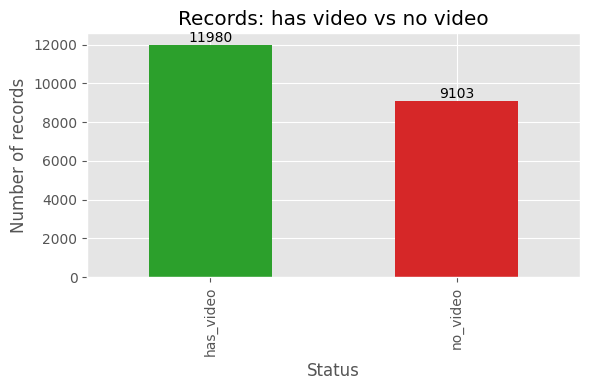

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'])
ax.set_title('Records: has video vs no video')
ax.set_xlabel('Status')
ax.set_ylabel('Number of records')
for i, v in enumerate(counts.values):
    ax.text(i, v, str(int(v)), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [10]:
df_has_video = df[has_video_clean == True].copy()
df_has_video.to_csv(OUTPUT_CSV, index=False)

print('Saved:', OUTPUT_CSV)
print('Shape (has_video=True only):', df_has_video.shape)
df_has_video.head()

Saved: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video.csv
Shape (has_video=True only): (11980, 12)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,book,aslbrick,kaggle_dataset/videos/69241.mp4,1,75.0,75.0,2.502,29.970030,118,True,1280.0,720.0
10,book,signschool,kaggle_dataset/videos/07069.mp4,1,30.0,30.0,1.251,23.976024,31,True,1280.0,720.0
17,book,startasl,kaggle_dataset/videos/07068.mp4,1,68.0,68.0,2.269,29.970000,36,True,736.0,414.0
22,book,asldeafined,kaggle_dataset/videos/07070.mp4,1,86.0,86.0,2.866,30.003489,59,True,640.0,480.0
24,book,aslsearch,kaggle_dataset/videos/07099.mp4,1,87.0,87.0,2.870,30.318841,12,True,720.0,400.0
